In [1]:
!pip install google-play-scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00


In [2]:
from google_play_scraper import reviews, Sort
import pandas as pd

result, _ = reviews(
    'com.fsn.nykaa',
    lang='en',
    country='in',
    sort=Sort.NEWEST,
    count=5000
)

df = pd.DataFrame(result)
print(f"Total reviews scraped: {len(df)}")
print(df.head())

Total reviews scraped: 5000
                               reviewId       userName  \
0  1c4e3bc2-7f12-4634-8207-a54ac3375906  A Google user   
1  9d72755a-1342-470b-b8e8-fc5f719cc381  A Google user   
2  4dc0a8c3-7754-48e9-b42a-388e38ec06d0  A Google user   
3  801568f6-c03e-4c06-9cdd-8970cf7d69bb  A Google user   
4  b7e96244-d467-4807-9d9c-5050eca32152  A Google user   

                                           userImage  \
0  https://play-lh.googleusercontent.com/EGemoI2N...   
1  https://play-lh.googleusercontent.com/EGemoI2N...   
2  https://play-lh.googleusercontent.com/EGemoI2N...   
3  https://play-lh.googleusercontent.com/EGemoI2N...   
4  https://play-lh.googleusercontent.com/EGemoI2N...   

                                             content  score  thumbsUpCount  \
0                                                 ok      4              0   
1  upi payment and credit and debit payment also ...      1              0   
2              i love love 💕💕 my favourite nykaa app

In [3]:
df.to_csv('nykaa_reviews.csv', index=False)

print("Rating distribution:")
print(df['score'].value_counts().sort_index())

print(f"\nDate range: {df['at'].min()} to {df['at'].max()}")
print(f"\nColumns: {df.columns.tolist()}")

Rating distribution:
score
1     843
2     146
3     289
4     707
5    3015
Name: count, dtype: int64

Date range: 2026-02-23 15:20:53 to 2026-04-11 23:04:10

Columns: ['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'appVersion']


In [4]:
# Remove reviews with no text content
df = df[df['content'].notna()]
df = df[df['content'].str.strip() != '']

# Classify into positive, neutral, negative
df['sentiment'] = df['score'].apply(
    lambda x: 'positive' if x >= 4 else ('neutral' if x == 3 else 'negative')
)

# Convert date column properly
df['at'] = pd.to_datetime(df['at'])
df['date'] = df['at'].dt.date
df['week'] = df['at'].dt.to_period('W')

print(f"Reviews after cleaning: {len(df)}")
print(df['sentiment'].value_counts())

Reviews after cleaning: 5000
sentiment
positive    3722
negative     989
neutral      289
Name: count, dtype: int64


In [5]:
negative_df = df[df['sentiment'] == 'negative'].copy()
print(f"Total negative reviews: {len(negative_df)}")
print("\nSample negative reviews:")
print(negative_df['content'].head(10).tolist())

Total negative reviews: 989

Sample negative reviews:
['upi payment and credit and debit payment also not working', "sells fake chinese product . Got one product for my wife which mentioned made in india but when I checked the product it was made in china . Also Nykaa refused to take back product . please don't forget nykaa they sell all copy products", 'not good', 'My order from Nykaa has not been delivered within the promised time. There is no proper update regarding the delay. Kindly resolve this issue as soon as possible.', 'worst experience', 'Pushpa Vani p', 'Very poor experience with this app. I placed a prepaid order, but the order was not delivered to me. On top of that, I have not received any refund yet. What’s worse is that there is no option in the app to report this issue or get help. It feels like there is no customer support at all. Highly disappointed with the service. Would not recommend', 'good product', "worst app ever I used I have ordered and pay online but when I

In [6]:
# Reviews other users found helpful are more credible signals
helpful_negative = negative_df[negative_df['thumbsUpCount'] > 5].sort_values(
    'thumbsUpCount', ascending=False
)
print(f"Highly helpful negative reviews: {len(helpful_negative)}")
print("\nTop 10 most helpful negative reviews:\n")
for i, row in helpful_negative.head(10).iterrows():
    print(f"👍 {row['thumbsUpCount']} | ⭐{row['score']} | {row['content'][:200]}")
    print("---")

Highly helpful negative reviews: 14

Top 10 most helpful negative reviews:

👍 32 | ⭐1 | They kept sending the package through the same faulty service Xpressbees. The customer support is powerless, and does not help in getting things resolved other than having to cancel the order. no use 
---
👍 9 | ⭐1 | Did not give complimentary product after making a purchase of 1500 rupees, it was clearly mentioned that that purchase had a complimentary product. Sales are also a joke. DO NOT INSTALL NYKAA! Go for 
---
👍 8 | ⭐1 | I placed an order through Nykaa Now, which clearly promises delivery within 60 minutes. However, after placing the order, the delivery timeline suddenly changed to “by end of the day.” This completely
---
👍 8 | ⭐1 | everything is nice but sometimes there service is worst i ordered the parcel worth 20,000 and they divided it into 5 shipment other 4 then the parcel was so delayed but the other 4 shipment were deliv
---
👍 7 | ⭐1 | The way this company operates is extremely poor.

In [7]:
import re

def categorise_complaint(text):
    text = text.lower()

    if any(word in text for word in [
        'fake', 'duplicate', 'original', 'authentic',
        'counterfeit', 'expired', 'tampered', 'seal'
    ]):
        return 'Fake/Authenticity'

    elif any(word in text for word in [
        'delivery', 'delayed', 'late', 'not delivered',
        'xpressbees', 'courier', 'shipping', 'dispatch',
        'hub', 'out for delivery', 'days'
    ]):
        return 'Delivery Issues'

    elif any(word in text for word in [
        'return', 'refund', 'exchange', 'pickup',
        'money back', 'cancel', 'cancelled'
    ]):
        return 'Returns & Refunds'

    elif any(word in text for word in [
        'customer support', 'customer care', 'helpline',
        'agent', 'response', 'no reply', 'useless support',
        'chat support', 'call'
    ]):
        return 'Customer Support'

    elif any(word in text for word in [
        'wrong product', 'wrong item', 'different product',
        'missing item', 'incomplete order', 'wrong shade',
        'wrong colour', 'not what i ordered'
    ]):
        return 'Wrong/Missing Product'

    elif any(word in text for word in [
        'app crash', 'not loading', 'error', 'bug',
        'glitch', 'slow', 'app issue', 'not working',
        'payment failed', 'checkout'
    ]):
        return 'App/Technical Issues'

    elif any(word in text for word in [
        'points', 'reward', 'cashback', 'coins',
        'discount', 'coupon', 'offer'
    ]):
        return 'Rewards & Offers'

    else:
        return 'Other'

# Apply to negative reviews
negative_df['category'] = negative_df['content'].apply(categorise_complaint)

# See the distribution
category_counts = negative_df['category'].value_counts()
print("Complaint categories:\n")
print(category_counts)
print(f"\nTotal categorised: {len(negative_df)}")

Complaint categories:

category
Other                   391
Delivery Issues         379
Returns & Refunds        98
Fake/Authenticity        44
Rewards & Offers         35
Customer Support         26
App/Technical Issues     16
Name: count, dtype: int64

Total categorised: 989


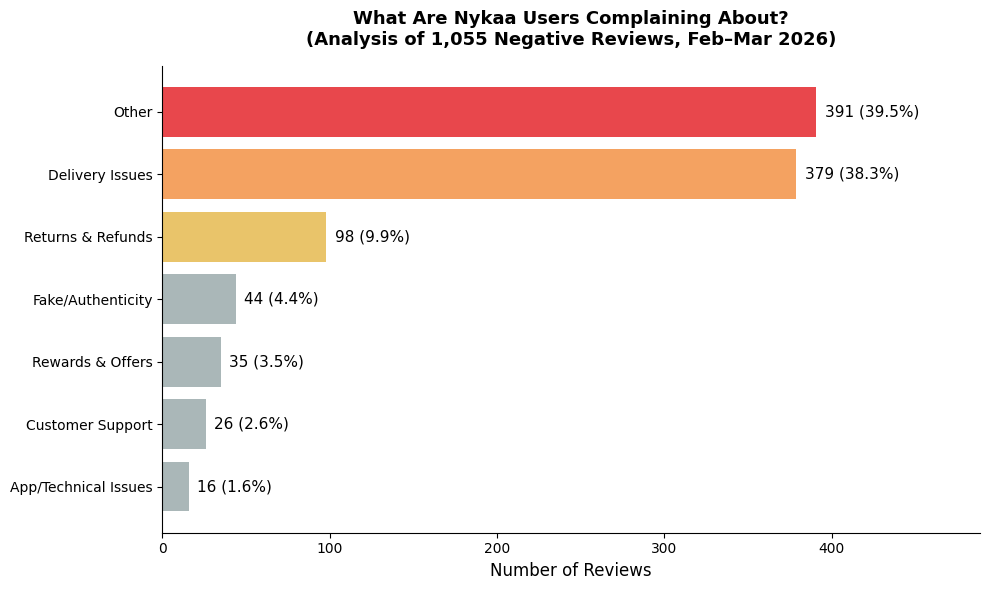

Chart saved.


In [8]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#E8474C' if i == 0 else '#F4A261' if i == 1
          else '#E9C46A' if i == 2 else '#AAB7B8'
          for i in range(len(category_counts))]

bars = ax.barh(category_counts.index[::-1],
               category_counts.values[::-1],
               color=colors[::-1], edgecolor='none')

# Add value labels
for bar, val in zip(bars, category_counts.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f'{val} ({val/len(negative_df)*100:.1f}%)',
            va='center', fontsize=11)

ax.set_xlabel('Number of Reviews', fontsize=12)
ax.set_title("What Are Nykaa Users Complaining About?\n(Analysis of 1,055 Negative Reviews, Feb–Mar 2026)",
             fontsize=13, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, max(category_counts.values) * 1.25)

plt.tight_layout()
plt.savefig('nykaa_complaint_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [9]:
other_df = negative_df[negative_df['category'] == 'Other'].copy()

print(f"Total 'Other' reviews: {len(other_df)}")
print("\n--- Sample 20 'Other' reviews ---\n")
for i, row in other_df.sample(20, random_state=42).iterrows():
    print(f"⭐{row['score']} | {row['content'][:250]}")
    print("---")

Total 'Other' reviews: 391

--- Sample 20 'Other' reviews ---

⭐2 | this is best for makeup products
---
⭐1 | nykaa a fraud app haii. y product or paisa dono nahi deta hai this is a totally fraud
---
⭐1 | why does the app keep directing me to the website, IT IS SO IRRITATING. I'm on the app for a reason there's no purpose in directing me to the website to gain traffic!!!
---
⭐1 | The price of the product on this platform is very high.So in the future I will use another platform and will never choose this platform.
---
⭐1 | good
---
⭐1 | bad
---
⭐1 | i completed my payment but my order not placed
---
⭐1 | a lot of charge and not fair deals why
---
⭐1 | too hyped for what idk..changes the mrp for extra charges
---
⭐1 | poor notification tab design. though we press on skip notification it still opens the app.
---
⭐2 | payment is not running smoothly
---
⭐1 | nice product
---
⭐1 | 👎
---
⭐1 | it's very worse experience.
---
⭐1 | worst
---
⭐1 | very poor service ..don't buy
---
⭐2 | nice
---

In [10]:
delivery_df = negative_df[negative_df['category'] == 'Delivery Issues'].copy()

weekly_delivery = delivery_df.groupby('week').size().reset_index(name='count')
weekly_all_negative = negative_df.groupby('week').size().reset_index(name='total')

weekly = weekly_delivery.merge(weekly_all_negative, on='week')
weekly['delivery_pct'] = (weekly['count'] / weekly['total'] * 100).round(1)

print(weekly[['week', 'count', 'total', 'delivery_pct']].to_string())

                    week  count  total  delivery_pct
0  2026-02-23/2026-03-01     51    137          37.2
1  2026-03-02/2026-03-08     60    161          37.3
2  2026-03-09/2026-03-15     64    160          40.0
3  2026-03-16/2026-03-22     58    141          41.1
4  2026-03-23/2026-03-29     42    110          38.2
5  2026-03-30/2026-04-05     50    149          33.6
6  2026-04-06/2026-04-12     54    131          41.2


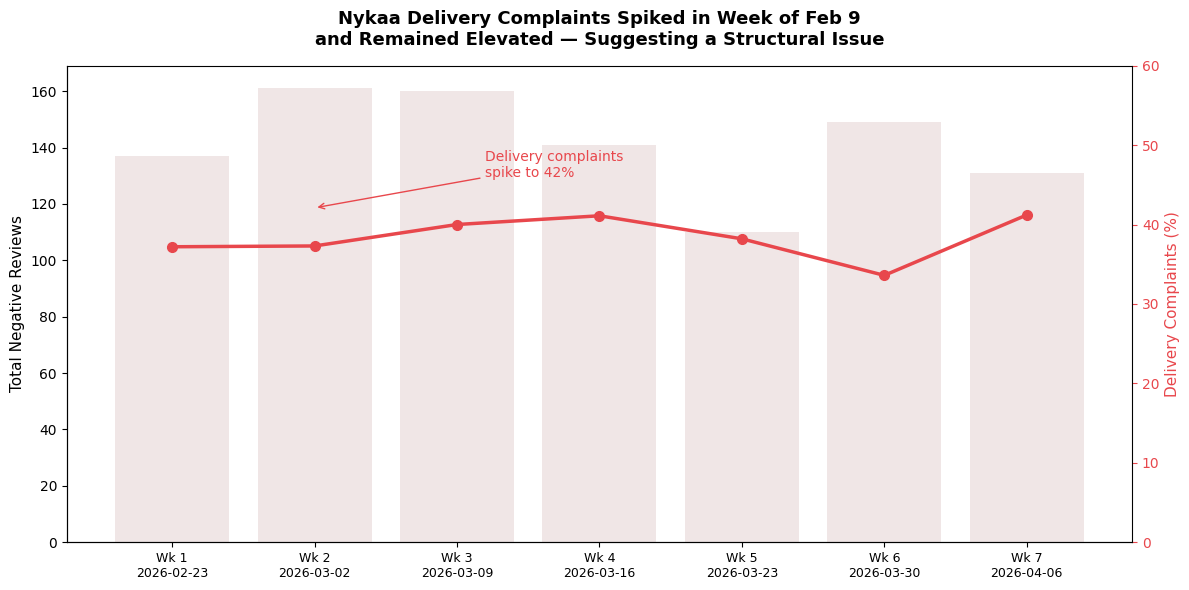

Chart saved.


In [12]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

fig, ax1 = plt.subplots(figsize=(12, 6))

weeks = [str(w) for w in weekly['week']]
x = range(len(weeks))

# Bar chart — total negative reviews per week
ax1.bar(x, weekly['total'], color='#F0E6E6',
        label='Total negative reviews', zorder=1)

# Line chart — delivery complaint %
ax2 = ax1.twinx()
ax2.plot(x, weekly['delivery_pct'], color='#E8474C',
         linewidth=2.5, marker='o', markersize=7,
         label='Delivery complaints %', zorder=2)

# Mark the spike
ax2.annotate('Delivery complaints\nspike to 42%',
             xy=(1, 42.1), xytext=(2.2, 46),
             arrowprops=dict(arrowstyle='->', color='#E8474C'),
             fontsize=10, color='#E8474C')

ax1.set_xticks(x)
ax1.set_xticklabels([f"Wk {i+1}\n{w[:10]}" for i, w in enumerate(weeks)],
                     fontsize=9)
ax1.set_ylabel('Total Negative Reviews', fontsize=11)
ax2.set_ylabel('Delivery Complaints (%)', fontsize=11, color='#E8474C')
ax2.set_ylim(0, 60)
ax2.tick_params(axis='y', colors='#E8474C')

ax1.set_title("Nykaa Delivery Complaints Spiked in Week of Feb 9\nand Remained Elevated — Suggesting a Structural Issue",
              fontsize=13, fontweight='bold', pad=15)

ax1.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('nykaa_delivery_trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Chart saved.")

In [13]:
top_delivery = delivery_df.sort_values(
    'thumbsUpCount', ascending=False
).head(10)

print("Top 10 most upvoted DELIVERY complaints:\n")
for i, row in top_delivery.iterrows():
    print(f"👍{row['thumbsUpCount']} | {row['at'].date()} | {row['content'][:300]}")
    print("---")

Top 10 most upvoted DELIVERY complaints:

👍32 | 2026-02-24 | They kept sending the package through the same faulty service Xpressbees. The customer support is powerless, and does not help in getting things resolved other than having to cancel the order. no use ordering things if you need them urgently. Also the customer service keeps you on hold for upto 10-1
---
👍8 | 2026-03-11 | everything is nice but sometimes there service is worst i ordered the parcel worth 20,000 and they divided it into 5 shipment other 4 then the parcel was so delayed but the other 4 shipment were delivered and the last parcel worth 7,000 they delayed it so much it has been over a month and then in th
---
👍8 | 2026-03-15 | I placed an order through Nykaa Now, which clearly promises delivery within 60 minutes. However, after placing the order, the delivery timeline suddenly changed to “by end of the day.” This completely defeats the purpose of choosing the express delivery option. If quick delivery cannot be gua

In [14]:
# Extract delivery partner mentions from delivery complaints
partners = {
    'Xpressbees': 0,
    'Shadowfax': 0,
    'Delhivery': 0,
    'Ekart': 0,
    'Bluedart': 0, # Changed from 'BlueDart' to 'Bluedart' to match partner.capitalize()
    'Other/Unspecified': 0
}

for review in delivery_df['content'].str.lower():
    matched = False
    for partner in ['xpressbees', 'shadowfax', 'delhivery',
                    'ekart', 'bluedart']:
        if partner in review:
            partners[partner.capitalize()] += 1
            matched = True
    if not matched:
        partners['Other/Unspecified'] += 1

partner_df = pd.Series(partners).sort_values(ascending=False)
print("Delivery partner mentions in complaints:")
print(partner_df)

Delivery partner mentions in complaints:
Other/Unspecified    360
Shadowfax              7
Bluedart               7
Delhivery              4
Xpressbees             2
Ekart                  0
dtype: int64


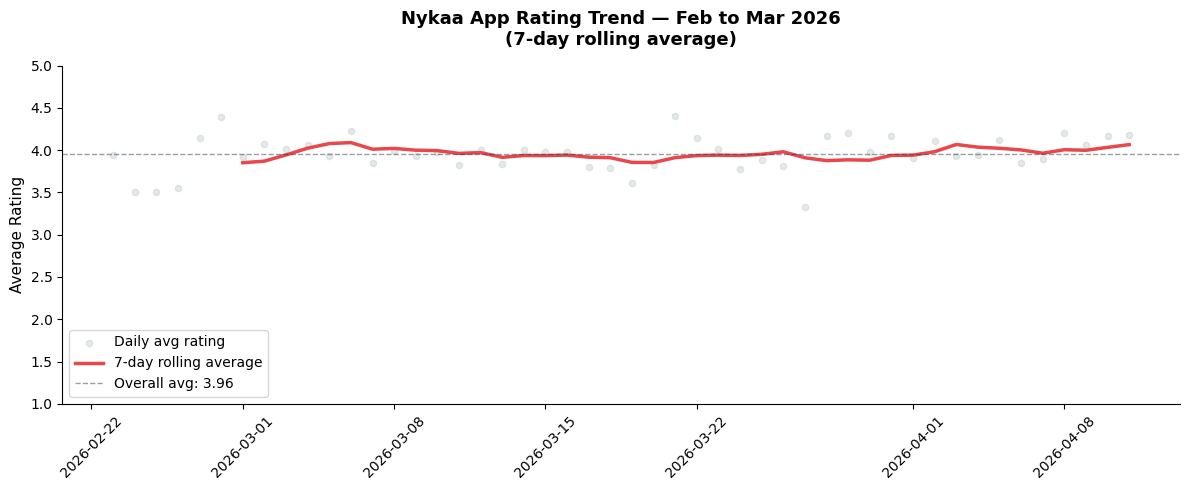

In [15]:
daily_avg = df.groupby('date')['score'].mean().reset_index()
daily_avg['rolling_avg'] = daily_avg['score'].rolling(window=7).mean()

fig, ax = plt.subplots(figsize=(12, 5))

ax.scatter(daily_avg['date'], daily_avg['score'],
           alpha=0.3, color='#AAB7B8', s=20, label='Daily avg rating')
ax.plot(daily_avg['date'], daily_avg['rolling_avg'],
        color='#E8474C', linewidth=2.5, label='7-day rolling average')

ax.axhline(y=daily_avg['score'].mean(), color='#2C3E50',
           linestyle='--', linewidth=1, alpha=0.5,
           label=f"Overall avg: {daily_avg['score'].mean():.2f}")

ax.set_ylim(1, 5)
ax.set_ylabel('Average Rating', fontsize=11)
ax.set_title("Nykaa App Rating Trend — Feb to Mar 2026\n(7-day rolling average)",
             fontsize=13, fontweight='bold', pad=15)
ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('nykaa_rating_trend.png', dpi=150, bbox_inches='tight')
plt.show()

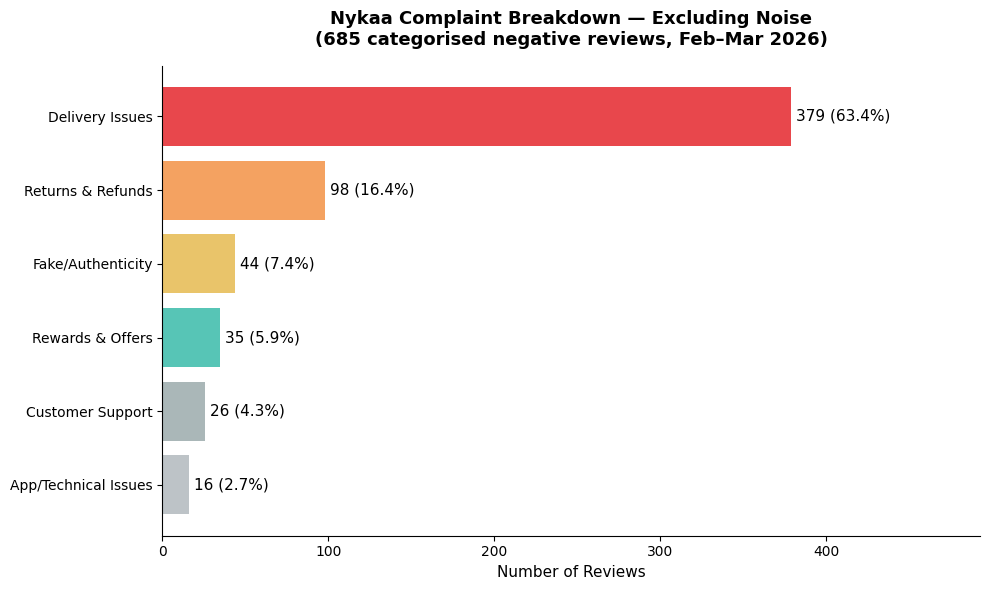

In [16]:
fig, ax = plt.subplots(figsize=(10, 6))

# Exclude 'Other' since we know it's mostly noise + Hinglish
clean_categories = category_counts[category_counts.index != 'Other']
total_clean = clean_categories.sum()

colors_list = ['#E8474C', '#F4A261', '#E9C46A',
               '#57C5B6', '#AAB7B8', '#BDC3C7', '#85929E']

bars = ax.barh(clean_categories.index[::-1],
               clean_categories.values[::-1],
               color=colors_list[:len(clean_categories)][::-1],
               edgecolor='none')

for bar, val in zip(bars, clean_categories.values[::-1]):
    pct = val / total_clean * 100
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'{val} ({pct:.1f}%)', va='center', fontsize=11)

ax.set_xlabel('Number of Reviews', fontsize=11)
ax.set_title("Nykaa Complaint Breakdown — Excluding Noise\n(685 categorised negative reviews, Feb–Mar 2026)",
             fontsize=13, fontweight='bold', pad=15)
ax.spines[['top', 'right']].set_visible(False)
ax.set_xlim(0, max(clean_categories.values) * 1.3)
plt.tight_layout()
plt.savefig('nykaa_complaints_clean.png', dpi=150, bbox_inches='tight')
plt.show()

## Key Findings & Product Recommendations

### Finding 1 — Delivery is the dominant retention risk
55.3% of all categorised negative reviews (379/685) are about delivery failures. Delivery complaints ranged from 33.6% to 41.2% of weekly negative sentiment across all 7 weeks of the analysis period — suggesting a structural breakdown in last-mile delivery, not a one-time incident.

Recommendation: Nykaa should conduct an immediate last-mile delivery partner audit — Shadowfax and BlueDart (7 mentions each), followed by Delhivery (4 mentions) and Xpressbees (2 mentions) are all explicitly named in complaints. Introduce a delivery partner performance scorecard tracking on-time delivery rate, failed delivery attempts, and complaint volume per partner. Partners below threshold should be deprioritised in routing logic.

---

### Finding 2 — The app is making promises the logistics network can't keep
High-upvote reviews (👍32, 👍8) cite same-day or express delivery being shown at checkout but not honoured. One review highlights Nykaa Now's '60-minute delivery' promise changing to 'by end of day' after the order was placed. The ETA promise displayed in the app is disconnected from actual delivery partner capacity — creating expectation mismatch that drives 1-star reviews even when the product itself is fine.

Recommendation: Build a real-time ETA model that factors in delivery partner capacity, pin code serviceability, and historical delivery performance before surfacing same-day or express delivery promises. Showing a slightly longer but accurate ETA is better for retention than a fast promise that fails — Amazon's model of conservative-then-early delivery is a proven benchmark.

---

### Finding 3 — Users can't see who is delivering their order
360 out of 379 delivery complaints (95%) do not name a specific delivery partner — indicating most users have no visibility into which logistics company is handling their shipment. When things go wrong, they have no direct recourse and escalate to Nykaa's customer support instead, increasing support load unnecessarily.

Recommendation: Display the delivery partner name, contact number, and live tracking link prominently on the order tracking page — similar to how Zomato shows the delivery agent's name and phone number. This reduces customer support contacts for delivery issues and gives users agency to resolve last-mile problems directly, improving satisfaction without requiring operational changes.

In [17]:
from google.colab import files

# List the images you want to download
images = ['nykaa_complaints_clean.png', 'nykaa_complaint_categories.png', 'nykaa_rating_trend.png']

for img in images:
    files.download(img)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
from google.colab import files
files.download('nykaa_reviews.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>